✓ Ready
Loading: C:\python\Intelligent_Sketch2CAD\intermediate_data\adaptive_cleaned_20260510_143013.jpg
Detected: 510 lines
Before merge: 510
After merge: 245

Classification:
  Horizontal: 86
  Vertical: 97
  Other: 62

Manual dimensions: {'width_mm': 857, 'height_mm': 1125, 'hole_position_mm': 914, 'small_dimensions_mm': [95, 102], 'range_mm': '60-70'}


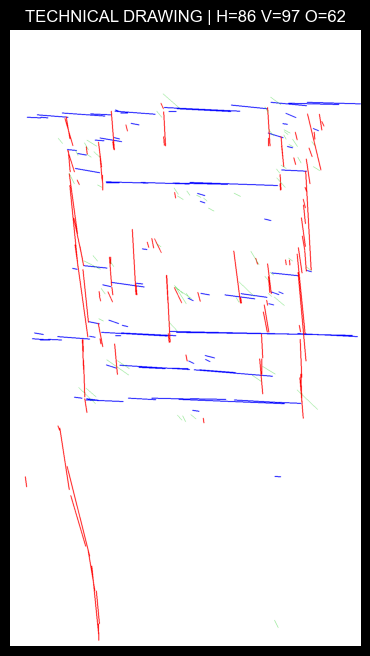


✅ VERTICAL SLICE DONE
   JSON: C:\python\Intelligent_Sketch2CAD\intermediate_data\technical_drawing_20260510_212228.json
   Image: C:\python\Intelligent_Sketch2CAD\intermediate_data\technical_drawing_20260510_212228.jpg

   Dimensions for CAD: 857 x 1125 mm
   Hole at: 914 mm

▶ Next: Import JSON to FreeCAD


In [8]:
# -------------------------------
# VERTICAL SLICE: SKETCH → TECHNICAL DRAWING
# -------------------------------
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import os
import json
from datetime import datetime

print("✓ Ready")

# -------------------------------
# PATHS
# -------------------------------
PROJECT_DIR = Path(r"C:\python\Intelligent_Sketch2CAD")
INTERMEDIATE_DIR = PROJECT_DIR / "intermediate_data"
INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------
# LOAD LATEST IMAGE
# -------------------------------
pattern = str(INTERMEDIATE_DIR / "adaptive_cleaned_*.jpg")
files = glob.glob(pattern)
latest_file = max(files, key=os.path.getctime)
print(f"Loading: {latest_file}")

image = cv2.imread(latest_file)
if len(image.shape) == 3:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
else:
    gray = image

# Fix polarity (white background, black lines)
if np.mean(gray) < 128:
    gray = cv2.bitwise_not(gray)
    print("Polarity fixed")

# -------------------------------
# LSD DETECTION
# -------------------------------
lsd = cv2.createLineSegmentDetector(0)
lines_raw = lsd.detect(gray)[0]

all_lines = []
if lines_raw is not None:
    for line in lines_raw:
        x1, y1, x2, y2 = line[0]
        length = np.sqrt((x2-x1)**2 + (y2-y1)**2)
        if length >= 15:  # ignore very short lines
            all_lines.append([int(x1), int(y1), int(x2), int(y2)])

print(f"Detected: {len(all_lines)} lines")

# -------------------------------
# SIMPLE MERGE (connect nearby segments)
# -------------------------------
def merge_lines(lines, max_gap=25):
    if len(lines) < 2:
        return lines

    merged = []
    used = [False] * len(lines)

    for i, line1 in enumerate(lines):
        if used[i]:
            continue

        x1, y1, x2, y2 = line1
        dx1 = x2 - x1
        dy1 = y2 - y1
        angle1 = np.degrees(np.arctan2(dy1, dx1)) % 180

        group = [line1]

        for j, line2 in enumerate(lines):
            if not used[j] and i != j:
                x3, y3, x4, y4 = line2
                dx2 = x4 - x3
                dy2 = y4 - y3
                angle2 = np.degrees(np.arctan2(dy2, dx2)) % 180

                angle_diff = min(abs(angle1 - angle2), 180 - abs(angle1 - angle2))
                if angle_diff > 10:
                    continue

                dist = min(
                    np.sqrt((x2-x3)**2 + (y2-y3)**2),
                    np.sqrt((x1-x4)**2 + (y1-y4)**2)
                )

                if dist < max_gap:
                    group.append(line2)
                    used[j] = True

        all_x = []
        all_y = []
        for line in group:
            all_x.extend([line[0], line[2]])
            all_y.extend([line[1], line[3]])

        merged.append([min(all_x), min(all_y), max(all_x), max(all_y)])
        used[i] = True

    return merged

print(f"Before merge: {len(all_lines)}")
all_lines = merge_lines(all_lines, max_gap=25)
print(f"After merge: {len(all_lines)}")

# -------------------------------
# CLASSIFY (Horizontal / Vertical / Other)
# -------------------------------
horizontal = []
vertical = []
other = []

for line in all_lines:
    x1, y1, x2, y2 = line
    dx = abs(x2 - x1)
    dy = abs(y2 - y1)

    if dx > dy * 2:
        horizontal.append(line)
    elif dy > dx * 2:
        vertical.append(line)
    else:
        other.append(line)

print(f"\nClassification:")
print(f"  Horizontal: {len(horizontal)}")
print(f"  Vertical: {len(vertical)}")
print(f"  Other: {len(other)}")

##################################################################

# -------------------------------
# MANUAL DIMENSIONS (from your drawing - you can edit these)
# -------------------------------
# Read from the drawing: 857, 1125, 914, 95, 102, 60-70
dimensions = {
    "width_mm": 857,
    "height_mm": 1125,
    "hole_position_mm": 914,
    "small_dimensions_mm": [95, 102],
    "range_mm": "60-70"
}

print(f"\nManual dimensions: {dimensions}")

# -------------------------------
# VISUALIZATION
# -------------------------------
overlay = np.ones((gray.shape[0], gray.shape[1], 3), dtype=np.uint8) * 255

for line in horizontal:
    x1, y1, x2, y2 = line
    cv2.line(overlay, (x1, y1), (x2, y2), (0, 0, 255), 2)

for line in vertical:
    x1, y1, x2, y2 = line
    cv2.line(overlay, (x1, y1), (x2, y2), (255, 0, 0), 2)

for line in other:
    x1, y1, x2, y2 = line
    cv2.line(overlay, (x1, y1), (x2, y2), (0, 200, 0), 1)

plt.figure(figsize=(12, 8))
plt.imshow(overlay)
plt.title(f"TECHNICAL DRAWING | H={len(horizontal)} V={len(vertical)} O={len(other)}")
plt.axis("off")
plt.show()

# -------------------------------
# SAVE RESULTS (JSON for CAD export)
# -------------------------------
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

data = {
    "timestamp": timestamp,
    "source_image": str(latest_file),
    "lines": {
        "total": len(all_lines),
        "horizontal": len(horizontal),
        "vertical": len(vertical),
        "other": len(other),
        "horizontal_lines": horizontal,
        "vertical_lines": vertical,
        "all_lines": all_lines
    },
    "dimensions": dimensions
}

json_path = INTERMEDIATE_DIR / f"technical_drawing_{timestamp}.json"
with open(json_path, 'w') as f:
    json.dump(data, f, indent=2)

# Save visualization
vis_path = INTERMEDIATE_DIR / f"technical_drawing_{timestamp}.jpg"
cv2.imwrite(str(vis_path), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

print(f"\n✅ VERTICAL SLICE DONE")
print(f"   JSON: {json_path}")
print(f"   Image: {vis_path}")
print(f"\n   Dimensions for CAD: {dimensions['width_mm']} x {dimensions['height_mm']} mm")
print(f"   Hole at: {dimensions['hole_position_mm']} mm")
print(f"\n▶ Next: Import JSON to FreeCAD")